100%|██████████| 9.91M/9.91M [00:00<00:00, 16.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 508kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.6MB/s]


Starting Conditional GAN training on cuda...
Epoch [1/20] Loss D: 0.0329, Loss G: 5.1142
Epoch [2/20] Loss D: 0.2093, Loss G: 2.8598
Epoch [3/20] Loss D: 0.2890, Loss G: 2.5700
Epoch [4/20] Loss D: 0.1761, Loss G: 3.8400
Epoch [5/20] Loss D: 0.3894, Loss G: 2.2605
Epoch [6/20] Loss D: 0.5580, Loss G: 1.5788
Epoch [7/20] Loss D: 0.4173, Loss G: 1.9053
Epoch [8/20] Loss D: 0.3483, Loss G: 1.6825
Epoch [9/20] Loss D: 0.4533, Loss G: 1.6969
Epoch [10/20] Loss D: 0.3719, Loss G: 2.0263
Epoch [11/20] Loss D: 0.5120, Loss G: 1.3943
Epoch [12/20] Loss D: 0.4117, Loss G: 1.6112
Epoch [13/20] Loss D: 0.5015, Loss G: 1.3587
Epoch [14/20] Loss D: 0.6446, Loss G: 1.1258
Epoch [15/20] Loss D: 0.5366, Loss G: 1.2735
Epoch [16/20] Loss D: 0.5303, Loss G: 1.4006
Epoch [17/20] Loss D: 0.5409, Loss G: 1.0377
Epoch [18/20] Loss D: 0.5392, Loss G: 1.1016
Epoch [19/20] Loss D: 0.6153, Loss G: 1.1288
Epoch [20/20] Loss D: 0.5759, Loss G: 1.2146


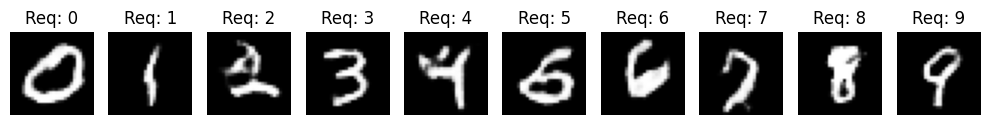

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# 1. Hyperparameters & Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
lr = 0.0002
z_dim = 100
num_classes = 10  # Digits 0-9
embed_size = 10   # Size of the vector representing our chosen digit
epochs = 20

# 2. Data Preparation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
dataset = datasets.MNIST(root="dataset/", train=True, transform=transform, download=True)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# 3. Conditional Generator (G)
class Generator(nn.Module):
    def __init__(self, z_dim, num_classes, embed_size):
        super().__init__()
        # This turns an integer (like '7') into a dense vector
        self.embed = nn.Embedding(num_classes, embed_size)

        self.gen = nn.Sequential(
            # Input dimension is now noise + label embedding
            nn.ConvTranspose2d(z_dim + embed_size, 256, 7, 1, 0),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 1, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        # Shape label embedding to (batch, embed_size, 1, 1)
        embedding = self.embed(labels).view(labels.shape[0], embed_size, 1, 1)
        # Shape noise to (batch, z_dim, 1, 1)
        noise = noise.view(noise.shape[0], z_dim, 1, 1)

        # Glue the noise and the label together!
        x = torch.cat([noise, embedding], dim=1)
        return self.gen(x)

# 4. Conditional Discriminator (D)
class Discriminator(nn.Module):
    def __init__(self, num_classes, img_size=28):
        super().__init__()
        self.img_size = img_size
        # We embed the label into a full 28x28 "image" mask to stack on top of the real/fake image
        self.embed = nn.Embedding(num_classes, img_size * img_size)

        self.disc = nn.Sequential(
            # Input channels: 1 for the image + 1 for the label mask = 2
            nn.Conv2d(2, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 1, 7, 1, 0),
            nn.Sigmoid()
        )

    def forward(self, image, labels):
        # Shape label embedding to (batch, 1, 28, 28)
        embedding = self.embed(labels).view(labels.shape[0], 1, self.img_size, self.img_size)

        # Glue the image and the label mask together!
        x = torch.cat([image, embedding], dim=1)
        return self.disc(x).view(-1, 1)

# 5. Initialize
gen = Generator(z_dim, num_classes, embed_size).to(device)
disc = Discriminator(num_classes).to(device)
opt_gen = optim.Adam(gen.parameters(), lr=lr)
opt_disc = optim.Adam(disc.parameters(), lr=lr)
criterion = nn.BCELoss()

# 6. Training Loop
print(f"Starting Conditional GAN training on {device}...")

for epoch in range(epochs):
    for batch_idx, (real_imgs, labels) in enumerate(loader):
        real_imgs = real_imgs.to(device)
        labels = labels.to(device) # We now need the actual labels from the dataset
        batch_size_curr = real_imgs.shape[0]

        ### Train Discriminator
        noise = torch.randn(batch_size_curr, z_dim).to(device)
        fake_imgs = gen(noise, labels) # Tell G to draw these specific labels

        disc_real = disc(real_imgs, labels).view(-1) # Tell D what label to check for
        loss_D_real = criterion(disc_real, torch.ones_like(disc_real))

        disc_fake = disc(fake_imgs.detach(), labels).view(-1)
        loss_D_fake = criterion(disc_fake, torch.zeros_like(disc_fake))

        loss_D = (loss_D_real + loss_D_fake) / 2
        disc.zero_grad()
        loss_D.backward()
        opt_disc.step()

        ### Train Generator
        output = disc(fake_imgs, labels).view(-1)
        loss_G = criterion(output, torch.ones_like(output))

        gen.zero_grad()
        loss_G.backward()
        opt_gen.step()

    print(f"Epoch [{epoch+1}/{epochs}] Loss D: {loss_D:.4f}, Loss G: {loss_G:.4f}")

# 7. The Fun Part: Asking for Specific Numbers!
with torch.no_grad():
    # We explicitly ask the model to generate the sequence 0, 1, 2, 3, 4, 5, 6, 7, 8, 9
    requested_labels = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]).to(device)
    test_noise = torch.randn(10, z_dim).to(device)

    # Generate the images
    generated_imgs = gen(test_noise, requested_labels).cpu().detach()

    plt.figure(figsize=(10, 2))
    for i in range(10):
        plt.subplot(1, 10, i+1)
        plt.imshow(generated_imgs[i].reshape(28, 28), cmap="gray")
        plt.title(f"Req: {i}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()